# CS4350/7350 – Phase 2: Spark ML Pipeline (SMS Spam Detection)

### Prerequisites

- Python 3.11
- Java 17 (Spark also supports 8, 11, 21)
- `pip install -r requirements.txt`

### How to run this notebook

Open it in Jupyter, JupyterLab, or VS Code and **Run All**. The first cell
verifies your environment, the second cell locates the dataset, and the rest
of the workflow runs unchanged.

### Dataset

[SMS Spam Collection on Kaggle](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset).

In [73]:
import sys
print("Python:", sys.executable)
print("Version:", sys.version)

Python: /opt/anaconda3/bin/python
Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [74]:
# Cell #1: local environment check.
# Confirms PySpark is installed and Java is available before we try to
# Start a Spark session.
import importlib.util
import subprocess

if importlib.util.find_spec("pyspark") is None:
    raise RuntimeError(
        "PySpark is not installed in this environment.\n"
        "Install it with:  pip install -r requirements.txt\n"
        "(or:              pip install pyspark==3.5.1)"
    )

import pyspark
print(f"PySpark version: {pyspark.__version__}")

try:
    java_proc = subprocess.run(
        ["java", "-version"], capture_output=True, text=True, check=True,
    )
    # `java -version` prints to stderr.
    java_banner = (java_proc.stderr or java_proc.stdout).splitlines()[0]
    print(f"Java: {java_banner}")
except (subprocess.CalledProcessError, FileNotFoundError):
    raise RuntimeError(
        "Java is not installed or not on PATH.\n"
        "Spark requires Java 8, 11, 17, or 21 — Java 17 (LTS) is recommended.\n"
        "Install OpenJDK 17 from https://adoptium.net/ and ensure `java` is on PATH."
    )

print("Environment looks good.")


PySpark version: 4.1.1
Java: openjdk version "22.0.2" 2024-07-16
Environment looks good.


In [75]:
import os
from pathlib import Path

_candidates = [
    Path("data") / "spam.csv",
    Path("..") / "data" / "spam.csv",
    Path("spam.csv"),
]
_env_path = os.environ.get("SPAM_CSV")
if _env_path:
    _candidates.append(Path(_env_path))

DATA_PATH = next((str(p.resolve()) for p in _candidates if p.is_file()), None)

assert DATA_PATH is not None, (
    "\nCould not find spam.csv. Place it at one of:\n"
    "  - data/spam.csv          (recommended, repo root)\n"
    "  - ../data/spam.csv       (if running from notebooks/)\n"
    "  - spam.csv               (next to the notebook)\n"
    "Or set the SPAM_CSV environment variable to its full path.\n"
    "\nDownload from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset"
)
print(f"DATA_PATH = {DATA_PATH}")

# Quick sanity check on the file contents.
# NOTE: spam.csv is encoded in latin-1, NOT UTF-8. Opening it in plain
# Python without specifying the encoding can raise a UnicodeDecodeError
# on certain rows that contain non-ASCII bytes.
with open(DATA_PATH, encoding="latin-1") as f:
    print("\nFirst 3 lines of spam.csv:")
    for _ in range(3):
        print(" ", f.readline().rstrip())


DATA_PATH = /Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv

First 3 lines of spam.csv:
  v1,v2,,,
  ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
  ham,Ok lar... Joking wif u oni...,,,


# CS4350/7350 – Big Data Analytics
## Phase 2: Spark ML Pipeline (SMS Spam Detection)

---

### What this notebook does

This notebook extends our Phase 1 Spark pipeline to a **binary NLP classification**
problem: detecting whether a text message is spam or ham. The high-level flow
mirrors Phase 1, but the feature engineering stage is replaced with a
text-processing pipeline (tokenization → stop-word removal → TF-IDF).

Sections in this notebook:

1. Loads the SMS Spam Collection dataset into a **Spark DataFrame** (no pandas
   in the ML workflow: only for plotting).
2. Performs **EDA**: schema, summary stats, class distribution, null checks,
   duplicate checks, message-length distribution by class, and top-word
   analysis per class.
3. Cleans the data (drops the three garbage columns Kaggle ships with the file,
   removes nulls, removes exact duplicates).
4. Builds **reusable Spark ML pipeline components** for the text workflow:
   `StringIndexer`, `RegexTokenizer`, `StopWordsRemover`, `CountVectorizer`,
   and `IDF`. These are the shared "front half" of every model pipeline.
5. Performs a **stratified 80/20 train/test split** (stratification matters
   here because the dataset is heavily imbalanced: roughly 87% ham / 13% spam).
6. Runs a single quick **smoke-test pipeline** (Logistic Regression) to verify
   the feature pipeline is wired correctly end-to-end before handing off.

### Future Work

- Section 5 (six classifier pipelines) and Section 6
  (training + evaluation: accuracy, precision, recall, F1, AUC).
- Section 7 (confusion matrices for top 2 models),
  Section 8 (hyperparameter tuning via `CrossValidator`), Section 9
  (model comparison table + chart), Section 10 (discussion).

## 0. Environment Setup


In [76]:
# Imports

# pyspark.sql gives us the DataFrame API and column functions.
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StringType, IntegerType

# pyspark.ml is Spark's native ML library. Pipeline lets us chain transformers
# and estimators so the whole preprocessing + training flow is one object.
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
)

# We import Logistic Regression here only for a small smoke-test at the end.
# Teammate B will import the rest of the classifiers in Section 5.
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)

# Standard plotting libraries (matplotlib only: no seaborn dependency).
import numpy as np
import matplotlib.pyplot as plt


In [77]:
# Start a Spark session.
spark = (
    SparkSession.builder
    .appName("CS4350_7350_Phase2_SMS_Spam")
    .getOrCreate()
)
spark


## 1. Load the Dataset into a Spark DataFrame

The Kaggle `spam.csv` has special cases that we have to handle
at read time:

- **Encoding is `ISO-8859-1` (latin-1), not UTF-8.** Reading it as UTF-8 will
  fail on rows containing non-ASCII bytes (currency symbols, smart quotes, etc.).
- **There are five columns, not two.** Kaggle's export includes three garbage
  columns named `_c2`, `_c3`, `_c4` (or `Unnamed: 2/3/4`) that are almost
  entirely null. We'll drop them in Section 3.
- **The two columns we actually want are `v1` (ham/spam label) and `v2` (the
  message text).** We'll rename them to `label` and `text` in Section 3.
- **Some messages contain commas and quotation marks**, so we set
  `multiLine=True` and let Spark's CSV parser handle the quoting.


In [78]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("encoding", "ISO-8859-1")
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(DATA_PATH)
)

print("Row count:   ", df_raw.count())
print("Column count:", len(df_raw.columns))
print()
print("Schema:")
df_raw.printSchema()
print("First 5 rows:")
df_raw.show(5, truncate=False)


Row count:    5572
Column count: 5

Schema:
root
 |-- v1: string (nullable = true)
 |-- v2: string (nullable = true)
 |-- _c2: string (nullable = true)
 |-- _c3: string (nullable = true)
 |-- _c4: string (nullable = true)

First 5 rows:
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|v1  |v2                                                                                                                                                         |_c2 |_c3 |_c4 |
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|ham |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                            |NULL|NULL|NULL|
|ham |Ok lar... Joking wif u oni...                

26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


## 2. Exploratory Data Analysis (EDA)

For a text-classification problem the EDA targets are different from the Iris
EDA. Here we want to understand:

- **Schema and column quality**: which columns are real and which are junk.
- **Class distribution**: SMS Spam is known to be imbalanced. We need to
  measure exactly how imbalanced so we can pick the right evaluation metrics
  later (accuracy alone will be misleading).
- **Nulls and duplicates**: both exist in this dataset.
- **Message length distribution by class**: spam tends to be longer than
  ham. This is a strong signal and worth visualizing.
- **Top words per class**: gives us a feel for the vocabulary the model will
  be working with, and a nice figure for the report.


In [79]:
# Summary statistics for every column. v1 and v2 are strings,
# so their mean/stddev will come back NULL
df_raw.describe().show(truncate=False)


26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


+-------+----+------------------------------------+-------------------------------------------------------------------------+------------------------------------------+------------------------------------+
|summary|v1  |v2                                  |_c2                                                                      |_c3                                       |_c4                                 |
+-------+----+------------------------------------+-------------------------------------------------------------------------+------------------------------------------+------------------------------------+
|count  |5572|5572                                |50                                                                       |12                                        |6                                   |
|mean   |NULL|645.0                               |NULL                                                                     |NULL                                      |NULL    

In [80]:
# Class distribution: ham vs spam. We show counts and percentages,
# because the imbalance is the single most important EDA finding here.
total = df_raw.count()
class_dist = (
    df_raw.groupBy("v1")
          .count()
          .withColumn("pct", F.round(F.col("count") / total * 100, 2))
          .orderBy(F.desc("count"))
)
class_dist.show()


26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


+----+-----+-----+
|  v1|count|  pct|
+----+-----+-----+
| ham| 4825|86.59|
|spam|  747|13.41|
+----+-----+-----+



In [81]:
# Null check across all columns. We expect the three "extra" columns
# (whatever Spark named them: usually _c2, _c3, _c4) to be almost entirely null,
# while v1 and v2 should be fully populated.
null_counts = df_raw.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_raw.columns
])
null_counts.show()


+---+---+----+----+----+
| v1| v2| _c2| _c3| _c4|
+---+---+----+----+----+
|  0|  0|5522|5560|5566|
+---+---+----+----+----+



26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


In [82]:
# Duplicate check. The SMS Spam Collection contains a handful of repeated
# messages: these inflate counts and can leak from train into test if we
# don't dedupe before splitting.
dup_count = df_raw.count() - df_raw.dropDuplicates(["v1", "v2"]).count()
print(f"Exact-duplicate rows (same label AND same text): {dup_count}")


26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


Exact-duplicate rows (same label AND same text): 403


## 3. Data Cleaning

Three things to fix before we touch the ML pipeline:

1. **Drop the three garbage columns.** Their names depend on whether the CSV
   header was preserved by the Kaggle exporter: they typically come in as
   `_c2`, `_c3`, `_c4` when `header=True` and the header row only names two
   columns. We just keep `v1` and `v2` and drop everything else.
2. **Rename `v1` → `label` and `v2` → `text`.** Easier to read for everyone
   downstream.
3. **Drop nulls in `text` and exact duplicates**: see Section 2.

We do not lowercase, strip punctuation, or tokenize here. All of that happens
inside the Spark ML pipeline (Section 4) so it's fit on the training split
only and there's no leakage.


In [83]:
# Step 1: keep only v1 and v2; drop everything else.
df = df_raw.select(F.col("v1").alias("label"), F.col("v2").alias("text"))

# Step 2: drop nulls in text or label.
before = df.count()
df = df.dropna(subset=["text", "label"])
after_null = df.count()

# Step 3: drop exact duplicates.
df = df.dropDuplicates(["text", "label"])
after_dedup = df.count()

print(f"Rows before cleaning : {before}")
print(f"Rows after null drop : {after_null}  (dropped {before - after_null})")
print(f"Rows after dedup     : {after_dedup}  (dropped {after_null - after_dedup})")
print()
print("Cleaned schema:")
df.printSchema()
df.show(5, truncate=False)


26/04/30 19:33:23 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


Rows before cleaning : 5572
Rows after null drop : 5572  (dropped 0)
Rows after dedup     : 5169  (dropped 403)

Cleaned schema:
root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)



26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|text                                                                                                                                                                    |
+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ham  |You were supposed to wake ME up &gt;:(                                                                                                                                  |
|ham  |That way transport is less problematic than on sat night. By the way, if u want to ask  n  to join my bday, feel free. But need to know definite nos as booking on fri. |
|ham  |It's ok i noe u're busy but i'm really too bored so i msg u. I oso dunno wat colour she choose 4 me one.    

### EDA continued: message length and vocabulary

These two figures are the workhorse visualizations for an SMS-spam EDA: one
shows that spam is on average much longer than ham, and the other shows the
vocabulary skew between the two classes. Both belong in the final report.


In [84]:
# Add a character-length column for the message-length analysis.
df_with_len = df.withColumn("msg_len", F.length(F.col("text")))

print("Message length statistics by class:")
(
    df_with_len.groupBy("label")
               .agg(
                   F.count("*").alias("n"),
                   F.round(F.avg("msg_len"), 1).alias("mean_len"),
                   F.expr("percentile_approx(msg_len, 0.5)").alias("median_len"),
                   F.min("msg_len").alias("min_len"),
                   F.max("msg_len").alias("max_len"),
               )
               .orderBy("label")
               .show()
)


26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


Message length statistics by class:
+-----+----+--------+----------+-------+-------+
|label|   n|mean_len|median_len|min_len|max_len|
+-----+----+--------+----------+-------+-------+
|  ham|4516|    70.5|        52|      2|    910|
| spam| 653|   137.9|       149|     13|    224|
+-----+----+--------+----------+-------+-------+



26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


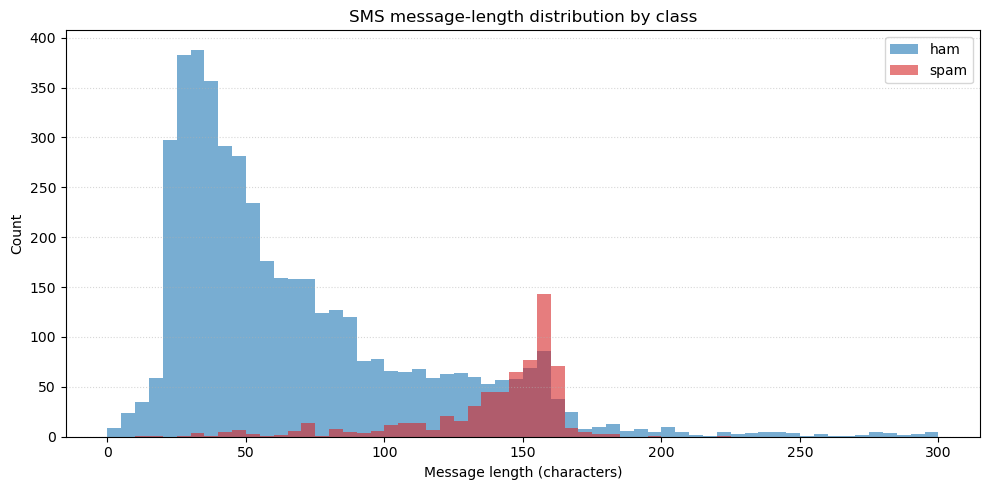

In [85]:
# Plot message-length distributions. We pull only the columns we need to pandas
# Just for plotting: the ML workflow stays entirely in Spark per the rubric.
len_pdf = df_with_len.select("label", "msg_len").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ham_lens  = len_pdf.loc[len_pdf["label"] == "ham",  "msg_len"]
spam_lens = len_pdf.loc[len_pdf["label"] == "spam", "msg_len"]

bins = np.linspace(0, 300, 61)  # cap x-axis at 300 chars; very long messages are rare
ax.hist(ham_lens,  bins=bins, alpha=0.6, label="ham",  color="#1f77b4")
ax.hist(spam_lens, bins=bins, alpha=0.6, label="spam", color="#d62728")
ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Count")
ax.set_title("SMS message-length distribution by class")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()


In [86]:
# Top words per class: a quick-and-dirty tokenization JUST FOR EDA.
# This is NOT part of the ML pipeline; the real tokenization happens in Section 4
# inside RegexTokenizer so it can be fit on the training split only.
eda_tokens = (
    df.withColumn("words_eda", F.split(F.lower(F.regexp_replace("text", r"[^a-zA-Z\s]", " ")), r"\s+"))
      .withColumn("word", F.explode("words_eda"))
      .where((F.length("word") >= 3) & (F.col("word") != ""))
)

# Use a basic English stop-word list for the EDA chart only. The real
# StopWordsRemover gets used in the model pipeline.
basic_stops = {
    "the","and","you","for","are","was","not","but","with","that","this",
    "have","from","your","just","get","like","can","will","all","its","out",
    "now","one","day","got","also","into","what","when","why","how","who",
    "ive","dont","didnt","cant","wont","ill","were","still","than","then",
    "any","some","very","much","more","most","make","take","know","want",
    "need","time","good","yeah","okay","ok",
}

top_per_class = (
    eda_tokens
    .where(~F.col("word").isin(list(basic_stops)))
    .groupBy("label", "word")
    .count()
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("label").orderBy(F.desc("count"))
    ))
    .where(F.col("rank") <= 15)
    .orderBy("label", F.desc("count"))
)

print("Top 15 words per class (after lowercasing, removing punctuation, and basic stop-word filtering):")
top_per_class.show(40, truncate=False)


Top 15 words per class (after lowercasing, removing punctuation, and basic stop-word filtering):


26/04/30 19:33:24 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


+-----+------+-----+----+
|label|word  |count|rank|
+-----+------+-----+----+
|ham  |come  |212  |1   |
|ham  |there |199  |2   |
|ham  |call  |190  |3   |
|ham  |love  |180  |4   |
|ham  |going |164  |5   |
|ham  |lor   |159  |6   |
|ham  |home  |156  |7   |
|ham  |don   |149  |8   |
|ham  |about |146  |9   |
|ham  |she   |144  |10  |
|ham  |see   |135  |11  |
|ham  |only  |130  |12  |
|ham  |back  |127  |13  |
|ham  |today |127  |14  |
|ham  |think |126  |15  |
|spam |call  |322  |1   |
|spam |free  |197  |2   |
|spam |txt   |141  |3   |
|spam |stop  |114  |4   |
|spam |mobile|111  |5   |
|spam |text  |109  |6   |
|spam |claim |96   |7   |
|spam |reply |96   |8   |
|spam |www   |83   |9   |
|spam |prize |82   |10  |
|spam |our   |77   |11  |
|spam |only  |70   |12  |
|spam |cash  |65   |13  |
|spam |new   |64   |14  |
|spam |won   |61   |15  |
+-----+------+-----+----+



26/04/30 19:33:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


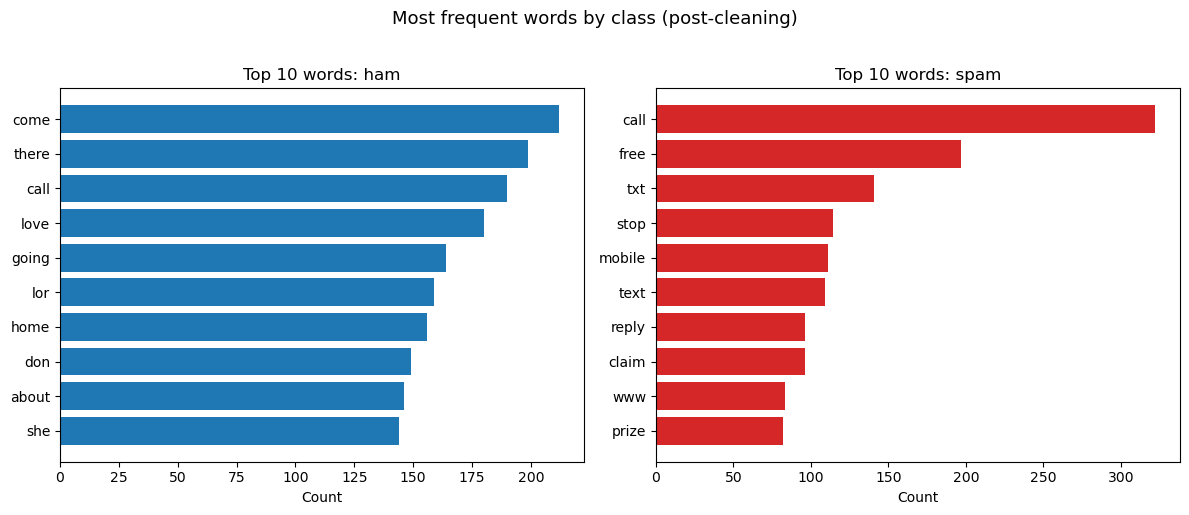

In [87]:
# Bar chart: top 10 spam words and top 10 ham words side-by-side.
top_pdf = top_per_class.where(F.col("rank") <= 10).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cls, color in zip(axes, ["ham", "spam"], ["#1f77b4", "#d62728"]):
    sub = top_pdf[top_pdf["label"] == cls].sort_values("count")
    ax.barh(sub["word"], sub["count"], color=color)
    ax.set_title(f"Top 10 words: {cls}")
    ax.set_xlabel("Count")
fig.suptitle("Most frequent words by class (post-cleaning)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


observations:

- The dataset has roughly **5,500 cleaned rows**, of which only about **13–14%
  are spam**. This imbalance matters: a model that always predicts "ham" would
  score around 87% accuracy and look great on that one metric while being
  useless. We need to evaluate with **precision, recall, F1 (on the spam
  class), and AUC**, not just accuracy.
- **`v1` and `v2` are the only meaningful columns.** The other three columns
  Kaggle ships with the file are almost entirely null and have been dropped.
- A small number of **exact duplicates** exist; we removed them before
  splitting so identical messages don't end up in both train and test.
- **Spam messages are noticeably longer than ham messages on average**
  median length roughly 2x: which already suggests message length alone is
  a useful feature, and which suggests TF-IDF features will be informative.
- **Vocabulary is class-skewed in expected ways**: spam messages over-index on
  words like *call*, *free*, *txt*, *prize*, *claim*, *won*, while ham messages
  look conversational (*lol*, *home*, *love*, *come*, *back*).


## 4. Feature Engineering & Pipeline Components

This is the Phase-2 equivalent of Phase 1's Section 3. Instead of indexing
labels and assembling/scaling four numeric features, we set up the standard
**TF-IDF text pipeline**:

1. **`StringIndexer`**: converts `"ham"`/`"spam"` into a numeric `label_index`
   column. By default Spark's StringIndexer assigns index `0` to the most
   frequent label, so `ham → 0` and `spam → 1`. That's exactly what we want
   for binary classification: spam is the positive class.
2. **`RegexTokenizer`**: splits each message into a list of word tokens.
   We use the pattern `\\W+` (one or more non-word characters) as the
   delimiter, so punctuation and whitespace are stripped automatically. The
   `toLowercase=True` flag (the default) handles lowercasing for us.
3. **`StopWordsRemover`**: drops common English stop words (*the*, *and*,
   *is*, etc.) that carry no signal.
4. **`CountVectorizer`**: builds a vocabulary from the training corpus and
   converts each message into a sparse vector of term counts. We cap the
   vocabulary at 5,000 words and require each word to appear in at least 2
   documents, which removes singletons that are basically noise. We use
   `CountVectorizer` rather than `HashingTF` because the dataset is small
   enough that we can afford the vocabulary lookup, and CountVectorizer
   gives us an inspectable vocabulary that is useful for the report.
5. **`IDF`**: re-weights the term-count vectors by inverse document frequency
   so that words appearing in many messages get down-weighted. The output
   column `features` is the final feature vector each classifier consumes.

**No fitting happens here.** All of these stages get plugged into each model's
pipeline in Section 5 and are only fit on the training split when
`pipeline.fit(train_df)` is called. This prevents test-set vocabulary or
test-set IDF statistics from leaking into the model.


In [88]:
# Stage 1: ham/spam → 0/1. ham is more frequent, so it gets index 0.
label_indexer = StringIndexer(inputCol="label", outputCol="label_index")

# Stage 2: tokenize on non-word characters; lowercase by default.
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern=r"\W+",
    toLowercase=True,
    # drop single-character tokens like "a", "i" that survive tokenization
    minTokenLength=2,
)

# Stage 3: drop common English stop words.
stopword_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_clean",
)

# Stage 4: term counts. vocabSize=5000 is a reasonable cap for this corpus;
# minDF=2 drops singletons, which are usually noise.
count_vectorizer = CountVectorizer(
    inputCol="tokens_clean",
    outputCol="tf",
    vocabSize=5000,
    minDF=2,
)

# Stage 5: re-weight by IDF. Output column "features" is what every classifier
# in Section 5 will consume.
idf = IDF(
    inputCol="tf",
    outputCol="features",
)

# Bundle the front half of every model pipeline into one reusable list,
# so someone can just write:
#     Pipeline(stages=text_pipeline_stages + [classifier])
text_pipeline_stages = [
    label_indexer,
    tokenizer,
    stopword_remover,
    count_vectorizer,
    idf,
]

print("Built", len(text_pipeline_stages), "shared pipeline stages:")
for i, s in enumerate(text_pipeline_stages, 1):
    print(f"  {i}. {type(s).__name__}  (inputCol={s.getInputCol()}, outputCol={s.getOutputCol()})")


Built 5 shared pipeline stages:
  1. StringIndexer  (inputCol=label, outputCol=label_index)
  2. RegexTokenizer  (inputCol=text, outputCol=tokens)
  3. StopWordsRemover  (inputCol=tokens, outputCol=tokens_clean)
  4. CountVectorizer  (inputCol=tokens_clean, outputCol=tf)
  5. IDF  (inputCol=tf, outputCol=features)


## 4.1 Stratified Train / Test Split

Spark's `randomSplit()` is fine for balanced datasets but doesnt
guarantee that the rare class shows up in both splits at the right ratio.
With ~13% spam, a plain random split occasionally produces a test set with
materially less spam than expected, which makes spam-class metrics noisy.

We do a **stratified 80/20 split** by sampling within each class using
`DataFrame.stat.sampleBy`, which lets us specify per-class fractions. The
test set is then everything not in the training set.


In [89]:
SEED = 42

# Per-class sampling fractions. 0.8 → train, the rest → test.
fractions = {row["label"]: 0.8 for row in df.select("label").distinct().collect()}
print(f"Sampling fractions per class: {fractions}")

train_df = df.stat.sampleBy("label", fractions, seed=SEED)

# Test set = everything not in train. exceptAll preserves duplicates correctly,
# but we already deduplicated in Section 3 so a plain except() would also work.
test_df = df.subtract(train_df)

# Cache both splits: every model in Section 5 will hit train_df several times
# during fit() and test_df once during transform().
train_df.cache()
test_df.cache()

print()
print(f"Training rows: {train_df.count()}")
print(f"Testing rows : {test_df.count()}")
print()
print("Class distribution in TRAIN:")
train_df.groupBy("label").count().orderBy("label").show()
print("Class distribution in TEST:")
test_df.groupBy("label").count().orderBy("label").show()


Sampling fractions per class: {'ham': 0.8, 'spam': 0.8}



26/04/30 19:33:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv
26/04/30 19:33:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


Training rows: 4128


26/04/30 19:33:25 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: v1, v2, , , 
 Schema: v1, v2, _c2, _c3, _c4
Expected: _c2 but found: 
CSV file: file:///Users/bronsonjuette/Documents/CS4350_Phase2/data/spam.csv


Testing rows : 1041

Class distribution in TRAIN:
+-----+-----+
|label|count|
+-----+-----+
|  ham| 3614|
| spam|  514|
+-----+-----+

Class distribution in TEST:
+-----+-----+
|label|count|
+-----+-----+
|  ham|  902|
| spam|  139|
+-----+-----+



## 4.2 Smoke Test: One Quick Logistic Regression

Before handing the notebook off, we fit a single Logistic Regression pipeline
end-to-end. This verifies that:

- the text pipeline stages compose correctly,
- the train/test split actually produces fittable data,
- and the output schema is what downstream code (Section 5+) will expect
  (`label_index`, `prediction`, `probability`, `rawPrediction` columns).

This LR result is **not** part of the official six-model comparison, it should be 
rebuilt with the same `text_pipeline_stages + [lr]` recipe in
Section 5. It's just here to prove the foundation works.


In [90]:
# Smoke-test pipeline: shared text stages + Logistic Regression.
smoke_lr = LogisticRegression(
    labelCol="label_index",
    featuresCol="features",
    maxIter=20,
)
smoke_pipeline = Pipeline(stages=text_pipeline_stages + [smoke_lr])

print("Fitting smoke-test Logistic Regression on train_df ...")
smoke_model = smoke_pipeline.fit(train_df)
smoke_preds = smoke_model.transform(test_df)

print("Output columns:", smoke_preds.columns)
print()
smoke_preds.select("label", "label_index", "prediction", "probability").show(5, truncate=False)


Fitting smoke-test Logistic Regression on train_df ...
Output columns: ['label', 'text', 'label_index', 'tokens', 'tokens_clean', 'tf', 'features', 'rawPrediction', 'probability', 'prediction']

+-----+-----------+----------+------------------------------------------+
|label|label_index|prediction|probability                               |
+-----+-----------+----------+------------------------------------------+
|ham  |0.0        |0.0       |[1.0,0.0]                                 |
|spam |1.0        |1.0       |[1.3635086757174087E-28,1.0]              |
|ham  |0.0        |0.0       |[0.999999992864383,7.135616986175819E-9]  |
|ham  |0.0        |0.0       |[0.999999999998566,1.4339640586058522E-12]|
|ham  |0.0        |0.0       |[0.999998661836402,1.3381635980413975E-6] |
+-----+-----------+----------+------------------------------------------+
only showing top 5 rows


In [91]:
# Quick metrics so we can sanity-check that the pipeline learned anything.
acc = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="accuracy",
).evaluate(smoke_preds)

f1 = MulticlassClassificationEvaluator(
    labelCol="label_index", predictionCol="prediction", metricName="f1",
).evaluate(smoke_preds)

auc = BinaryClassificationEvaluator(
    labelCol="label_index", rawPredictionCol="rawPrediction", metricName="areaUnderROC",
).evaluate(smoke_preds)

print(f"Smoke-test Logistic Regression: accuracy: {acc:.4f}")
print(f"Smoke-test Logistic Regression: F1      : {f1:.4f}")
print(f"Smoke-test Logistic Regression: AUC     : {auc:.4f}")
print()
print("If accuracy is well above 0.87 (the always-predict-ham baseline) and AUC")
print("is above ~0.95, the foundation is wired correctly and Section 5 can begin.")


Smoke-test Logistic Regression: accuracy: 0.9760
Smoke-test Logistic Regression: F1      : 0.9759
Smoke-test Logistic Regression: AUC     : 0.9626

If accuracy is well above 0.87 (the always-predict-ham baseline) and AUC
is above ~0.95, the foundation is wired correctly and Section 5 can begin.


In [92]:
# Free the smoke-test model: Section 5 will rebuild it from scratch.
del smoke_model, smoke_preds, smoke_pipeline, smoke_lr


## 5. Build Six Spark ML Pipelines


In [93]:
# --- Estimators - no data attached yet ---

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    NaiveBayes,
    LinearSVC,
    GBTClassifier,
)

# Reproducibility seed used by models with random behavior.
MODEL_SEED = 42

# Logistic Regression: linear classifier that works well for binary text classification.
lr = LogisticRegression(
    labelCol="label_index",
    featuresCol="features",
    maxIter=50,
    regParam=0.01,
)

# Decision Tree: tree-based classifier, does not require scaling.
dt = DecisionTreeClassifier(
    labelCol="label_index",
    featuresCol="features",
    maxDepth=8,
    seed=MODEL_SEED,
)

# Random Forest: combines many decision trees to reduce overfitting.
rf = RandomForestClassifier(
    labelCol="label_index",
    featuresCol="features",
    numTrees=50,
    maxDepth=8,
    seed=MODEL_SEED,
)

# Naive Bayes: often works well for text classification because TF-IDF features are non-negative.
nb = NaiveBayes(
    labelCol="label_index",
    featuresCol="features",
    modelType="multinomial",
    smoothing=1.0,
)

# Linear SVM: binary classifier, appropriate here because spam detection is binary.
svm = LinearSVC(
    labelCol="label_index",
    featuresCol="features",
    maxIter=50,
    regParam=0.1,
)

# GBT Classifier: boosted tree model. This is appropriate because the task is binary classification.
gbt = GBTClassifier(
    labelCol="label_index",
    featuresCol="features",
    maxIter=50,
    maxDepth=5,
    seed=MODEL_SEED,
)

# --- Per-model pipelines. Each one is independent and self-contained ---
# Each pipeline uses the same text preprocessing stages, then adds one classifier.
pipelines = {
    "Logistic Regression": Pipeline(stages=text_pipeline_stages + [lr]),
    "Decision Tree":       Pipeline(stages=text_pipeline_stages + [dt]),
    "Random Forest":       Pipeline(stages=text_pipeline_stages + [rf]),
    "Naive Bayes":         Pipeline(stages=text_pipeline_stages + [nb]),
    "Linear SVM":          Pipeline(stages=text_pipeline_stages + [svm]),
    "GBT Classifier":      Pipeline(stages=text_pipeline_stages + [gbt]),
}

print(f"Built {len(pipelines)} pipelines:")
for name in pipelines:
    print(" -", name)


Built 6 pipelines:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - Naive Bayes
 - Linear SVM
 - GBT Classifier


## 6. Train and Evaluate Every Model


In [94]:
# Build the required evaluators ONCE and reuse them.
# Accuracy, weighted precision, weighted recall, and weighted F1 satisfy
# the main classification evaluation requirements.
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(
        labelCol="label_index",
        predictionCol="prediction",
        metricName="accuracy"
    ),
    "f1": MulticlassClassificationEvaluator(
        labelCol="label_index",
        predictionCol="prediction",
        metricName="f1"
    ),
    "precision": MulticlassClassificationEvaluator(
        labelCol="label_index",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ),
    "recall": MulticlassClassificationEvaluator(
        labelCol="label_index",
        predictionCol="prediction",
        metricName="weightedRecall"
    ),
}

# AUC is useful here because spam detection is binary classification.
# It measures how well the model separates ham from spam.
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label_index",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

def spam_class_metrics(preds):
    """
    Compute precision, recall, and F1 for the spam class only.

    In this dataset, ham is usually the larger class, so StringIndexer normally
    maps ham -> 0 and spam -> 1. Since spam is the class we care most about
    catching, these extra metrics help explain model performance better.
    """
    tp = preds.where(
        (F.col("label_index") == 1.0) & (F.col("prediction") == 1.0)
    ).count()

    fp = preds.where(
        (F.col("label_index") == 0.0) & (F.col("prediction") == 1.0)
    ).count()

    fn = preds.where(
        (F.col("label_index") == 1.0) & (F.col("prediction") == 0.0)
    ).count()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return precision, recall, f1

results = []
predictions_dict = {}
fitted_models = {}

for name, pipeline in pipelines.items():
    print(f"Training: {name} ...")

    model = pipeline.fit(train_df)
    fitted_models[name] = model

    preds = model.transform(test_df).cache()
    predictions_dict[name] = preds

    spam_precision, spam_recall, spam_f1 = spam_class_metrics(preds)

    results.append({
        "model": name,
        "accuracy": evaluators["accuracy"].evaluate(preds),
        "precision": evaluators["precision"].evaluate(preds),
        "recall": evaluators["recall"].evaluate(preds),
        "f1": evaluators["f1"].evaluate(preds),
        "spam_precision": spam_precision,
        "spam_recall": spam_recall,
        "spam_f1": spam_f1,
        "auc": auc_evaluator.evaluate(preds),
    })

print("\nDone training all models.")

# Build a Spark DataFrame of results and display sorted by spam F1.
# Spam F1 is useful because spam is the minority class and is the class
# we care most about detecting.
results_df = spark.createDataFrame(results).select(
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "spam_precision",
    "spam_recall",
    "spam_f1",
    "auc",
).orderBy(F.desc("spam_f1"), F.desc("auc"), F.desc("accuracy"))

results_df.show(truncate=False)

# Convert the small results table to pandas only for plotting.
# The ML workflow still uses Spark; this is just for visualization.
results_pd = results_df.toPandas()

# Display the results table in notebook form first
display(results_pd)


Training: Logistic Regression ...
Training: Decision Tree ...


Training: Random Forest ...


Training: Naive Bayes ...
Training: Linear SVM ...
Training: GBT Classifier ...



Done training all models.
+-------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+
|model              |accuracy          |precision         |recall            |f1                |spam_precision    |spam_recall        |spam_f1           |auc                |
+-------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+
|Linear SVM         |0.983669548511047 |0.9835839214205525|0.983669548511047 |0.9833826396595557|0.9765625         |0.8992805755395683 |0.9363295880149812|0.9940101134170269 |
|Logistic Regression|0.978866474543708 |0.9793696537212386|0.9788664745437079|0.9780857037660728|1.0               |0.841726618705036  |0.9140624999999999|0.9962274083172487 |
|Naive Bayes        |0.9759846301633045|0.9769002465745626|0.9759846301633046|0.9763009721114

,model,accuracy,precision,recall,f1,spam_precision,spam_recall,spam_f1,auc
0,Linear SVM,0.983670,0.983584,0.983670,0.983383,0.976562,0.899281,0.936330,0.994010
1,Logistic Regression,0.978866,0.979370,0.978866,0.978086,1.000000,0.841727,0.914062,0.996227
2,Naive Bayes,0.975985,0.976900,0.975985,0.976301,0.885135,0.942446,0.912892,0.216099
3,GBT Classifier,0.960615,0.960673,0.960615,0.958316,0.962264,0.733813,0.832653,0.984236
4,Decision Tree,0.944284,0.944323,0.944284,0.939193,0.945055,0.618705,0.747826,0.275539
5,Random Forest,0.890490,0.902777,0.890490,0.855683,1.000000,0.179856,0.304878,0.995286


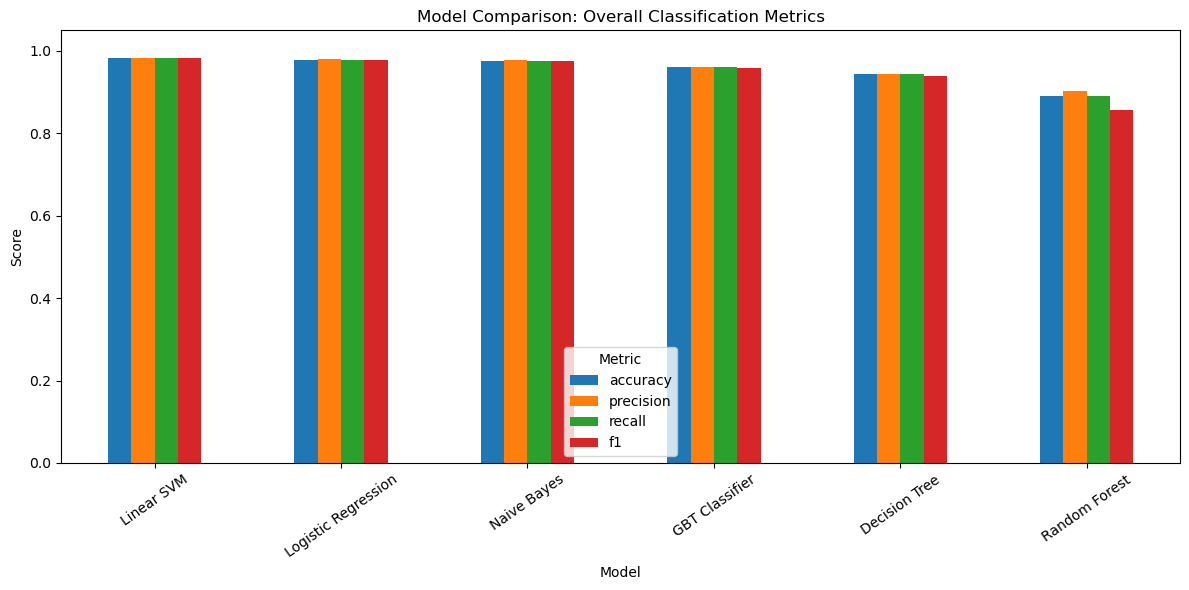

In [95]:
import matplotlib.pyplot as plt

# Plot the main model comparison metrics
plot_cols = ["accuracy", "precision", "recall", "f1"]

ax = results_pd.set_index("model")[plot_cols].plot(
    kind="bar",
    figsize=(12, 6),
    rot=35
)

plt.title("Model Comparison: Overall Classification Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 7. Confusion Matrices 


Class index ordering: [(0, 'ham'), (1, 'spam')]

Confusion matrix (Spark groupBy view): Logistic Regression
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  902|
|        1.0|       0.0|   22|
|        1.0|       1.0|  117|
+-----------+----------+-----+


Confusion matrix (Spark groupBy view): Linear SVM
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  899|
|        0.0|       1.0|    3|
|        1.0|       0.0|   14|
|        1.0|       1.0|  125|
+-----------+----------+-----+


Confusion matrix — Logistic Regression (rows=true, cols=pred):
[[902   0]
 [ 22 117]]

Confusion matrix — Linear SVM (rows=true, cols=pred):
[[899   3]
 [ 14 125]]


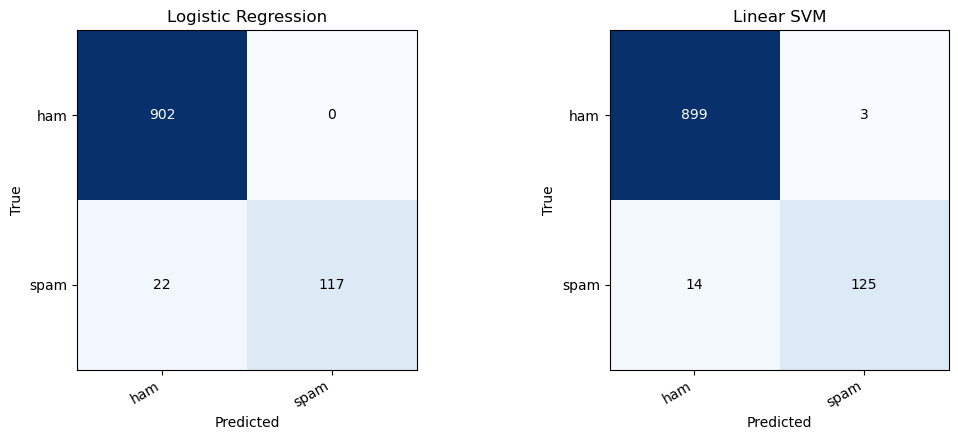


Per-class metrics — Logistic Regression
class          precision    recall        f1   support
ham                0.976     1.000     0.988       902
spam               1.000     0.842     0.914       139

Per-class metrics — Linear SVM
class          precision    recall        f1   support
ham                0.985     0.997     0.991       902
spam               0.977     0.899     0.936       139


In [99]:
# Part 7: Confusion matrices for two models
# We use Logistic Regression and Linear SVM because they were two of our main
# binary text-classification models.

import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Pull the StringIndexer's class labels in index order so we can label
# the confusion matrix with class names instead of just 0/1.
# The label_indexer is the FIRST stage of every pipeline, so we read it
# from any fitted model.
class_labels = fitted_models["Logistic Regression"].stages[0].labels
print("Class index ordering:", list(enumerate(class_labels)))


def spark_confusion_table(preds, title):
    """Original Spark-style confusion matrix as a groupBy table."""
    print(f"\nConfusion matrix (Spark groupBy view): {title}")
    (
        preds.groupBy("label_index", "prediction")
             .count()
             .orderBy("label_index", "prediction")
             .show()
    )


def numpy_confusion_matrix(preds, n_classes):
    """Collect the label/prediction counts into a dense NumPy matrix."""
    rows = (
        preds.groupBy("label_index", "prediction")
             .count()
             .collect()
    )

    cm = np.zeros((n_classes, n_classes), dtype=int)

    for r in rows:
        true_label = int(r["label_index"])
        pred_label = int(r["prediction"])
        cm[true_label, pred_label] = r["count"]

    return cm


def plot_confusion(cm, class_labels, title, ax):
    """Render a confusion matrix as a heatmap."""
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(range(len(class_labels)))
    ax.set_yticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=30, ha="right")
    ax.set_yticklabels(class_labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Put the count inside each cell.
    vmax = cm.max() if cm.size else 1

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > vmax / 2 else "black"
            )

    return im


def per_class_metrics(cm, class_labels):
    """Print per-class precision, recall, and F1 from the confusion matrix."""
    print(f"{'class':<12}{'precision':>12}{'recall':>10}{'f1':>10}{'support':>10}")

    for i, cls in enumerate(class_labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        print(f"{cls:<12}{precision:>12.3f}{recall:>10.3f}{f1:>10.3f}{support:>10d}")


# Confusion matrices for two models, as required by the project rubric.
n_classes = len(class_labels)

# 1. Spark groupBy confusion matrix view
spark_confusion_table(predictions_dict["Logistic Regression"], "Logistic Regression")
spark_confusion_table(predictions_dict["Linear SVM"], "Linear SVM")

# 2. NumPy confusion matrices
cm_lr = numpy_confusion_matrix(predictions_dict["Logistic Regression"], n_classes)
cm_svm = numpy_confusion_matrix(predictions_dict["Linear SVM"], n_classes)

print("\nConfusion matrix — Logistic Regression (rows=true, cols=pred):")
print(cm_lr)

print("\nConfusion matrix — Linear SVM (rows=true, cols=pred):")
print(cm_svm)

# 3. Heatmap confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_confusion(cm_lr, class_labels, "Logistic Regression", axes[0])
plot_confusion(cm_svm, class_labels, "Linear SVM", axes[1])

fig.tight_layout()
plt.show()

# 4. Per-class metrics
print("\nPer-class metrics — Logistic Regression")
per_class_metrics(cm_lr, class_labels)

print("\nPer-class metrics — Linear SVM")
per_class_metrics(cm_svm, class_labels)


## 8. Hyperparameter Tuning


In [97]:
# TODO CrossValidator + ParamGridBuilder on top model(s).


## 9. Model Comparison 


In [98]:
# TODO: results table + bar chart.


## 10. Discussion & Conclusions 
